# Reflectorch inference → NeXus/HDF5
### C60:DIP gradient thin film, 51 XRR positions

This notebook runs **reflectorch** inference on every position of the C60:DIP gradient sample and saves **everything** (raw counts, processed curves, fitted parameters, prior bounds, model config, sample/instrument/user metadata) into **one NeXus/HDF5 file**.

The structure follows the same idea as the `DataSaver` in **pygid / mlgid**: `entry → data / instrument / sample / process / user`, with provenance (program, version, model YAML) stored inside the file.




## 0. Install

In [1]:
!pip -q install reflectorch spec2nexus h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.1 MB/s eta 0:00:00


In [2]:
# Base GP stack
!pip install gpytorch botorch

# Clone reflectorch (master branch) so you can browse / edit the folders
%cd /content
!git clone -b master https://github.com/schreiber-lab/reflectorch.git

# Install from the clone in editable mode -> edits to the files take effect directly
%cd /content/reflectorch
!pip install -e .

!pip install nflows chainconsumer h5py spec2nexus
%cd /content

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 17.6 MB/s eta 0:00:00
/content
Cloning into 'reflectorch'...
remote: Enumerating objects: 4924, done.
remote: Counting objects: 100% (534/534), done.
remote: Compressing objects: 100% (306/306), done.
remote: Total 4924 (delta 335), reused 329 (delta 227), pack-reused 4390 (from 2)
Receiving objects: 100% (4924/4924), 271.93 MiB | 17.97 MiB/s, done.
Resolving deltas: 100% (3430/3430), done.
/content/reflectorch
Obtaining file:///content/reflectorch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for reflectorch (pypr

In [3]:
!pip install  gpytorch botorch

!pip install  "git+https://github.com/schreiber-lab/reflectorch.git"

!pip install  nflows chainconsumer


  Cloning https://github.com/schreiber-lab/reflectorch.git to /tmp/pip-req-build-021w88e1
  Running command git clone --filter=blob:none --quiet https://github.com/schreiber-lab/reflectorch.git /tmp/pip-req-build-021w88e1
  Resolved https://github.com/schreiber-lab/reflectorch.git to commit 7f41b740e54a01a8fd3799f4c22b8af33516d41d
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for reflectorch: filename=reflectorch-1.5.1-py3-none-any.whl size=159403 sha256=fea83e45eec56692dc8db65f3bf216ff0e9aff6013a47338ed805e5bf16f0594
  Stored in directory: /tmp/pip-ephem-wheel-cache-ob28qnlv/wheels/a3/c7/c9/880177c64c4274f3414ba0360ca82d1abac8722804981ccf99
Successfully built reflectorch
  Attempting uninstall: reflectorch
    Found existing installation: reflectorch 1.5.1
    Uninstalling reflectorch-1.5.1:
      Successfully uninstalled reflectorch-1.5.1


## 1. The NeXus saver
This cell writes `reflectorch_nexus_saver.py` next to the notebook. In the library it lives at `reflectorch/inference/reflectorch_nexus_saver.py`.

One function, `write_reflectorch_nexus(...)`, writes the whole file. The parameter table (`PARAM_SPECS`) says which parameters go in the file, with names, units and bound names.

In [4]:
!pip -q install -e /content/reflectorch spec2nexus h5py

import sys
sys.path.insert(0, "/content/reflectorch")   # use the clone, not the repo folder name
import os
from google.colab import files

SPEC_FILE, CSV_FILE = "240503_C60_DIP_grad.spec", "240503_C60_DIP_XRR_profiles.csv"
if not (os.path.exists(SPEC_FILE) and os.path.exists(CSV_FILE)):
    files.upload()

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for reflectorch (pyproject.toml) ... done


Saving 240503_C60_DIP_grad.spec to 240503_C60_DIP_grad.spec


## 2. Upload the data files
Skips the upload if the files are already there (e.g. after a re-run).

In [5]:
import os

SPEC_FILE = "240503_C60_DIP_grad.spec"
CSV_FILE  = "240503_C60_DIP_XRR_profiles.csv"

missing = [f for f in (SPEC_FILE, CSV_FILE) if not os.path.exists(f)]
if missing:
    from google.colab import files
    print("Please upload:", missing)
    files.upload()

for f in (SPEC_FILE, CSV_FILE):
    print(f"{f:40s}", "OK" if os.path.exists(f) else "MISSING")

Please upload: ['240503_C60_DIP_XRR_profiles.csv']


Saving 240503_C60_DIP_XRR_profiles.csv to 240503_C60_DIP_XRR_profiles.csv
240503_C60_DIP_grad.spec                 OK
240503_C60_DIP_XRR_profiles.csv          OK


## 3. Configuration

In [11]:
import sys, re
import numpy as np
import torch
from spec2nexus import spec

REPO = "/content/reflectorch"          # clone folder into Colab
sys.path.insert(0, REPO)
for m in [m for m in sys.modules if m == "reflectorch" or m.startswith("reflectorch.")]:
    del sys.modules[m]

from reflectorch import EasyInferenceModel
from reflectorch.inference.reflectorch_nexus_saver import write_reflectorch_nexus, save_prediction_dict_to_nexus, PARAM_SPECS


In [14]:
import re, numpy as np, pandas as pd, torch, h5py
import matplotlib.pyplot as plt
from spec2nexus import spec
from reflectorch import EasyInferenceModel
from reflectorch.inference.reflectorch_nexus_saver import write_reflectorch_nexus, add_reflectorch_output

OUTPUT_H5   = "xrr_C60_DIP_multiscan_reflectorch.h5"
CONFIG_NAME = "g_mc_point_xray_intconv_standard_L1_InputQ_size1024"
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
WAVELENGTH  = 1.5405452421779864   # Angstrom
TRIM_POINTS = 10                   # low-angle points removed in the reduction
SETUP_SCANS = {9, 15, 80}          # alignment scans

# prior bounds per model parameter, SLDs in 1e-6 A^-2
PRIOR_BOUNDS = {
    "Thickness L1": (150, 350),   "Roughness L1": (0, 55),   "Roughness sub": (0, 10),
    "SLD L1": (9, 14),            "SLD sub": (19.5, 20.5),
    "q_shift": (-0.002, 0.002),   "r_scale": (0.9, 1.1),
}
LABEL_TO_SCHEMA = {"Thickness L1": "thick", "Roughness L1": "rough", "SLD L1": "SLD",
                   "Roughness sub": "Si_rough", "r_scale": "r_scale", "q_shift": "q_shift"}

In [15]:
R_all = np.loadtxt(CSV_FILE, delimiter=",")[:, 1:].T          # (51, 91)
n_scans, n_q = R_all.shape

sp = spec.SpecDataFile(SPEC_FILE)
scan_nums = sorted(int(s.scanNum) for s in sp.scans.values()
                   if re.search(r"a2scan\s+th 0 1\s+tth 0 1\s+100", s.scanCmd)
                   and int(s.scanNum) not in SETUP_SCANS)
scans = [sp.getScan(n) for n in scan_nums]

raw_I     = np.vstack([np.array(s.data["Specular"])[TRIM_POINTS:] for s in scans])
two_theta = np.vstack([(np.array(s.data["Theta"]) + np.array(s.data["Two Theta"]))[TRIM_POINTS:] for s in scans])
y_motor   = np.array([float(s.positioner["Y"]) for s in scans])

q        = 4 * np.pi / WAVELENGTH * np.sin(np.deg2rad(two_theta[0] / 2))
dR_all   = R_all / np.sqrt(raw_I)
coord    = y_motor[::-1].copy()                                    # sample coordinate [mm]
frac_C60 = (coord - coord.min()) / (coord.max() - coord.min())     # linear gradient
print(f"{n_scans} curves x {n_q} points, coord {coord[0]:+.1f} ... {coord[-1]:+.1f} mm")

51 curves x 91 points, coord +27.5 ... -22.5 mm


In [16]:
model  = EasyInferenceModel(config_name=CONFIG_NAME, device=DEVICE)
labels = model.trainer.loader.prior_sampler.param_model.get_param_labels()
prior_bounds = [PRIOR_BOUNDS[l] for l in labels]

nan = lambda *s: np.full(s, np.nan)
out = dict(predicted_params=nan(n_scans, len(labels)), polished_params=nan(n_scans, len(labels)),
           polished_params_error=nan(n_scans, len(labels)),
           predicted_curve=nan(n_scans, n_q), polished_curve=nan(n_scans, n_q),
           sld_xaxis=[], predicted_sld_profile=[], polished_sld_profile=[])

for i in range(n_scans):
    kw = dict(reflectivity_curve=R_all[i], q_values=q, sigmas=dR_all[i], prior_bounds=prior_bounds,
              use_sigmas_for_polishing=True, calc_pred_curve=True, calc_pred_sld_profile=True)
    try:
        d = model.preprocess_and_predict(polish_prediction=True, calc_polished_sld_profile=True, **kw)
    except RuntimeError:
        print(f"scan {i + 1}: polishing failed -> prediction only")
        d = model.preprocess_and_predict(polish_prediction=False, **kw)
    out["predicted_params"][i] = d["predicted_params_array"]
    out["predicted_curve"][i]  = np.interp(q, d["q_plot_pred"], d["predicted_curve"], left=np.nan, right=np.nan)
    out["sld_xaxis"].append(d["predicted_sld_xaxis"])
    out["predicted_sld_profile"].append(d["predicted_sld_profile"])
    out["polished_sld_profile"].append(d.get("sld_profile_polished", np.full_like(d["predicted_sld_profile"], np.nan)))
    if "polished_params_array" in d:
        out["polished_params"][i]       = d["polished_params_array"]
        out["polished_params_error"][i] = d["polished_params_error_array"]
        out["polished_curve"][i]        = d["polished_curve"]
for k in ("sld_xaxis", "predicted_sld_profile", "polished_sld_profile"):
    out[k] = np.vstack(out[k])

table = pd.DataFrame({"coord [mm]": coord})
for j, l in enumerate(labels):
    table[f"{l} pred"], table[f"{l} pol"] = out["predicted_params"][:, j], out["polished_params"][:, j]
table.round(3)

Configuration file `/content/reflectorch/configs/g_mc_point_xray_intconv_standard_L1_InputQ_size1024.yaml` not found locally.


Weights file `/content/reflectorch/saved_models/model_g_mc_point_xray_intconv_standard_L1_InputQ_size1024.safetensors` not found locally.
Model g_mc_point_xray_intconv_standard_L1_InputQ_size1024 loaded. Number of parameters: 21.88 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 500.0]
- roughnesses: [0.0, 60.0]
- slds: [0.0, 50.0]
- q_shift: [-0.002, 0.002]
- r_scale: [0.9, 1.1]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- q_shift: [1e-05, 0.004]
- r_scale: [0.001, 0.2]
The following quantities are additional inputs to the network: prior bounds.


,coord [mm],Thickness L1 pred,Thickness L1 pol,Roughness L1 pred,Roughness L1 pol,Roughness sub pred,Roughness sub pol,SLD L1 pred,SLD L1 pol,SLD sub pred,SLD sub pol,q_shift pred,q_shift pol,r_scale pred,r_scale pol
0,27.503,205.753,208.597,12.315,13.563,8.444,4.175,13.348,13.929,20.082,20.500,0.000,-0.000,0.928,0.909
1,26.504,205.740,208.962,12.293,13.306,8.167,3.965,13.281,13.910,20.117,20.500,0.000,-0.000,0.936,0.918
2,25.577,205.233,208.170,12.669,13.423,7.688,4.278,13.364,13.898,20.104,20.500,0.000,0.000,0.927,0.905
3,24.575,203.974,207.442,12.299,13.046,7.411,3.973,13.357,13.933,20.109,20.500,0.000,0.000,0.934,0.913
4,23.571,204.859,207.962,11.260,11.927,6.785,3.496,13.394,13.911,20.137,20.500,0.000,0.000,0.936,0.918
5,22.569,207.116,209.691,10.070,10.381,6.116,3.756,13.519,13.904,20.199,20.500,0.000,-0.000,0.935,0.918
6,21.565,210.038,212.491,9.167,8.705,5.696,4.718,13.644,13.927,20.211,20.500,0.000,0.000,0.949,0.923
7,20.562,212.034,215.303,8.180,7.652,4.614,3.860,13.698,13.953,20.234,20.500,0.000,-0.000,0.948,0.922
8,19.559,213.544,217.722,7.799,7.397,4.603,3.503,13.649,13.972,20.244,20.500,0.000,0.000,0.953,0.925
9,18.557,216.779,220.112,7.977,7.538,4.992,3.942,13.574,13.894,20.227,20.500,0.000,-0.000,0.945,0.923


In [17]:
model  = EasyInferenceModel(config_name=CONFIG_NAME, device=DEVICE)
labels = model.trainer.loader.prior_sampler.param_model.get_param_labels()
prior_bounds = [PRIOR_BOUNDS[l] for l in labels]

nan = lambda *s: np.full(s, np.nan)
out = dict(predicted_params=nan(n_scans, len(labels)), polished_params=nan(n_scans, len(labels)),
           polished_params_error=nan(n_scans, len(labels)),
           predicted_curve=nan(n_scans, n_q), polished_curve=nan(n_scans, n_q),
           sld_xaxis=[], predicted_sld_profile=[], polished_sld_profile=[])

for i in range(n_scans):
    kw = dict(reflectivity_curve=R_all[i], q_values=q, sigmas=dR_all[i], prior_bounds=prior_bounds,
              use_sigmas_for_polishing=True, calc_pred_curve=True, calc_pred_sld_profile=True)
    try:
        d = model.preprocess_and_predict(polish_prediction=True, calc_polished_sld_profile=True, **kw)
    except RuntimeError:
        print(f"scan {i + 1}: polishing failed -> prediction only")
        d = model.preprocess_and_predict(polish_prediction=False, **kw)
    out["predicted_params"][i] = d["predicted_params_array"]
    out["predicted_curve"][i]  = np.interp(q, d["q_plot_pred"], d["predicted_curve"], left=np.nan, right=np.nan)
    out["sld_xaxis"].append(d["predicted_sld_xaxis"])
    out["predicted_sld_profile"].append(d["predicted_sld_profile"])
    out["polished_sld_profile"].append(d.get("sld_profile_polished", np.full_like(d["predicted_sld_profile"], np.nan)))
    if "polished_params_array" in d:
        out["polished_params"][i]       = d["polished_params_array"]
        out["polished_params_error"][i] = d["polished_params_error_array"]
        out["polished_curve"][i]        = d["polished_curve"]
for k in ("sld_xaxis", "predicted_sld_profile", "polished_sld_profile"):
    out[k] = np.vstack(out[k])

table = pd.DataFrame({"coord [mm]": coord})
for j, l in enumerate(labels):
    table[f"{l} pred"], table[f"{l} pol"] = out["predicted_params"][:, j], out["polished_params"][:, j]
table.round(3)

Configuration file `/content/reflectorch/configs/g_mc_point_xray_intconv_standard_L1_InputQ_size1024.yaml` found locally.
Weights file `/content/reflectorch/saved_models/model_g_mc_point_xray_intconv_standard_L1_InputQ_size1024.safetensors` found locally.
Model g_mc_point_xray_intconv_standard_L1_InputQ_size1024 loaded. Number of parameters: 21.88 M
The model corresponds to a `standard_model` parameterization with 1 layers (7 predicted parameters)
Parameter types and total ranges:
- thicknesses: [1.0, 500.0]
- roughnesses: [0.0, 60.0]
- slds: [0.0, 50.0]
- q_shift: [-0.002, 0.002]
- r_scale: [0.9, 1.1]
Allowed widths of the prior bound intervals (max-min):
- thicknesses: [0.01, 500.0]
- roughnesses: [0.01, 60.0]
- slds: [0.01, 5.0]
- q_shift: [1e-05, 0.004]
- r_scale: [0.001, 0.2]
The following quantities are additional inputs to the network: prior bounds.


,coord [mm],Thickness L1 pred,Thickness L1 pol,Roughness L1 pred,Roughness L1 pol,Roughness sub pred,Roughness sub pol,SLD L1 pred,SLD L1 pol,SLD sub pred,SLD sub pol,q_shift pred,q_shift pol,r_scale pred,r_scale pol
0,27.503,205.753,208.597,12.315,13.563,8.444,4.175,13.348,13.929,20.082,20.500,0.000,-0.000,0.928,0.909
1,26.504,205.740,208.962,12.293,13.306,8.167,3.965,13.281,13.910,20.117,20.500,0.000,-0.000,0.936,0.918
2,25.577,205.233,208.170,12.669,13.423,7.688,4.278,13.364,13.898,20.104,20.500,0.000,0.000,0.927,0.905
3,24.575,203.974,207.442,12.299,13.046,7.411,3.973,13.357,13.933,20.109,20.500,0.000,0.000,0.934,0.913
4,23.571,204.859,207.962,11.260,11.927,6.785,3.496,13.394,13.911,20.137,20.500,0.000,0.000,0.936,0.918
5,22.569,207.116,209.691,10.070,10.381,6.116,3.756,13.519,13.904,20.199,20.500,0.000,-0.000,0.935,0.918
6,21.565,210.038,212.491,9.167,8.705,5.696,4.718,13.644,13.927,20.211,20.500,0.000,0.000,0.949,0.923
7,20.562,212.034,215.303,8.180,7.652,4.614,3.860,13.698,13.953,20.234,20.500,0.000,-0.000,0.948,0.922
8,19.559,213.544,217.722,7.799,7.397,4.603,3.503,13.649,13.972,20.244,20.500,0.000,0.000,0.953,0.925
9,18.557,216.779,220.112,7.977,7.538,4.992,3.942,13.574,13.894,20.227,20.500,0.000,-0.000,0.945,0.923


In [18]:
idx = {LABEL_TO_SCHEMA[l]: j for j, l in enumerate(labels) if l in LABEL_TO_SCHEMA}
write_reflectorch_nexus(
    OUTPUT_H5, q=q, R=R_all, dR=dR_all, coord=coord,
    predicted={n: out["predicted_params"][:, j] for n, j in idx.items()},
    polished={n: out["polished_params"][:, j] for n, j in idx.items()},
    prior_bounds={LABEL_TO_SCHEMA[l]: PRIOR_BOUNDS[l] for l in LABEL_TO_SCHEMA},
    model_yaml=(model.config_dir / model.config_name).read_text(),
    material_names=("C60", "DIP"), fractions=np.column_stack([frac_C60, 1 - frac_C60]),
    raw_intensity=raw_I, two_theta=two_theta, y_motor=y_motor,
    scan_numbers=scan_nums, timestamps=[s.date for s in scans], filename=SPEC_FILE,
)
add_reflectorch_output(OUTPUT_H5, {"param_names": labels, "prior_bounds": np.array(prior_bounds), "q": q, **out})
files.download(OUTPUT_H5)

NeXus file written -> /content/xrr_C60_DIP_multiscan_reflectorch.h5 [entry_0000] (51 scans x 91 q-points, 6 parameters)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

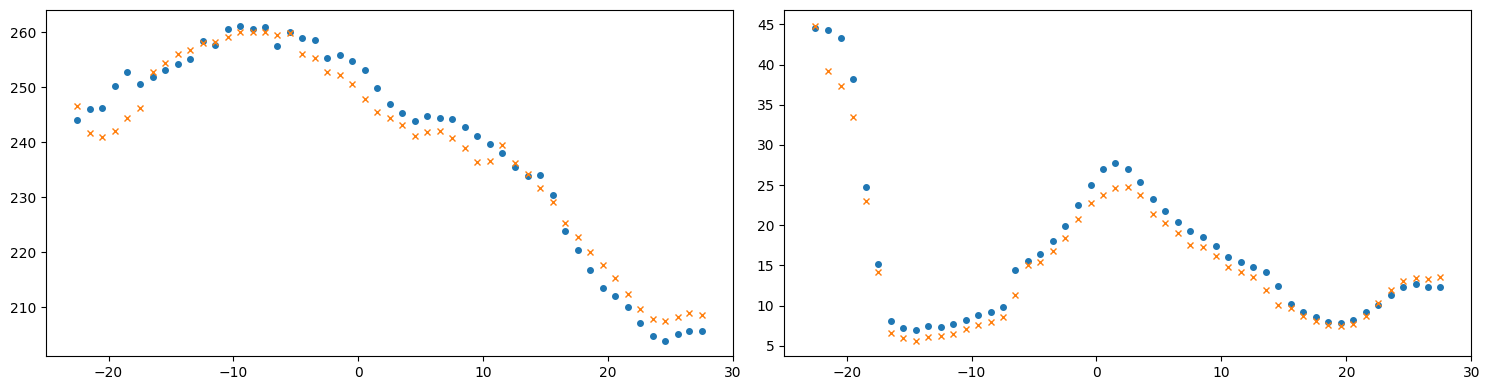

In [20]:
with h5py.File(OUTPUT_H5, "r") as f:
    a = f["entry_0000/data/analysis"]
    c, res, units = a["coord"][:], {n: a[n][:] for n in ("thick", "rough", "SLD")}, {n: a[n].attrs["units"] for n in ("thick", "rough", "SLD")}

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, n in zip(axes, res):
    ax.plot(c, res[n]["Predicted"], "o", ms=4, label="predicted")
    ax.plot(c, res[n]["Polished"], "x", ms=5, label="polished")
plt.tight_layout(); plt.show()